# Extreme Pollution Event Analysis

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from scipy.stats import mannwhitneyu

import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.stats.multitest import multipletests

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

sns.set_theme(style="whitegrid")

In [2]:
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"

TABLES_DIR = (
    REPORTS_DIR /
    "tables" /
    "phase7_extreme_events"
)

TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
hourly = pd.read_csv(
    PROCESSED_DIR /
    "air_quality_features.csv",
    parse_dates=['time'],
    index_col='time'
)

daily = pd.read_csv(
    PROCESSED_DIR /
    "air_quality_daily.csv",
    parse_dates=['time'],
    index_col='time'
)

In [4]:
print("Hourly:", hourly.shape)
print("Daily:", daily.shape)

print(
    "Hourly period:",
    hourly.index.min(),
    "to",
    hourly.index.max()
)

print(
    "Hourly frequency:",
    pd.infer_freq(hourly.index)
)

Hourly: (23352, 43)
Daily: (973, 30)
Hourly period: 2022-09-01 00:00:00 to 2025-04-30 23:00:00
Hourly frequency: h


In [5]:
season_order = [
    'Winter',
    'Pre-Monsoon',
    'Monsoon',
    'Post-Monsoon'
]

wind_order = [
    'N', 'NE', 'E', 'SE',
    'S', 'SW', 'W', 'NW'
]

hourly['season'] = pd.Categorical(
    hourly['season'],
    categories=season_order,
    ordered=True
)

daily['season'] = pd.Categorical(
    daily['season'],
    categories=season_order,
    ordered=True
)

hourly['wind_sector'] = pd.Categorical(
    hourly['wind_sector'],
    categories=wind_order,
    ordered=True
)

## Confirm extreme thresholds

In [6]:
pm25_p90 = hourly['pm25'].quantile(0.90)
pm25_p95 = hourly['pm25'].quantile(0.95)

print(
    f"90th percentile: {pm25_p90:.2f}"
)

print(
    f"95th percentile: {pm25_p95:.2f}"
)

90th percentile: 66.10
95th percentile: 83.60


In [7]:
print(
    "Top-10% hours:",
    hourly['pm25_top10'].sum()
)

print(
    "Top-5% hours:",
    hourly['pm25_top5'].sum()
)

print(
    "Top-10% percentage:",
    hourly['pm25_top10'].mean() * 100
)

print(
    "Top-5% percentage:",
    hourly['pm25_top5'].mean() * 100
)

Top-10% hours: 2354
Top-5% hours: 1177
Top-10% percentage: 10.080507022953066
Top-5% percentage: 5.040253511476533


In [9]:
#consecutive PM2.5 episodes (Episode-detection function)
def build_hourly_episode_table(
    df,
    flag_col,
    threshold,
    value_col='pm25'
):

    temp = df.copy()

    flag = (
        temp[flag_col]
        .astype(bool)
    )

    # True only when a new episode begins
    temp['episode_start'] = (
        flag
        & ~flag.shift(
            1,
            fill_value=False
        )
    )

    temp['episode_id'] = (
        temp['episode_start']
        .cumsum()
    )

    # Non-extreme observations do not belong
    # to an episode
    temp.loc[
        ~flag,
        'episode_id'
    ] = np.nan

    event_hours = (
        temp.loc[flag]
        .copy()
    )

    event_hours[
        'episode_id'
    ] = (
        event_hours[
            'episode_id'
        ]
        .astype(int)
    )

    # Excess concentration above threshold
    event_hours[
        'excess_pm25'
    ] = (
        event_hours[value_col]
        - threshold
    ).clip(lower=0)

    event_reset = (
        event_hours
        .reset_index()
    )

    episodes = (
        event_reset
        .groupby('episode_id')
        .agg(
            start_time=(
                'time',
                'min'
            ),

            end_time=(
                'time',
                'max'
            ),

            duration_hours=(
                'time',
                'size'
            ),

            mean_pm25=(
                value_col,
                'mean'
            ),

            median_pm25=(
                value_col,
                'median'
            ),

            peak_pm25=(
                value_col,
                'max'
            ),

            cumulative_pm25=(
                value_col,
                'sum'
            ),

            excess_burden=(
                'excess_pm25',
                'sum'
            ),

            mean_temperature=(
                'temperature',
                'mean'
            ),

            mean_humidity=(
                'humidity',
                'mean'
            ),

            total_rain=(
                'rain',
                'sum'
            ),

            mean_wind_speed=(
                'wind_speed',
                'mean'
            ),

            mean_pressure=(
                'pressure',
                'mean'
            )
        )
    )

    # Time of episode peak
    peak_idx = (
        event_reset
        .groupby(
            'episode_id'
        )[value_col]
        .idxmax()
    )

    peak_times = (
        event_reset
        .loc[
            peak_idx,
            [
                'episode_id',
                'time'
            ]
        ]
        .set_index(
            'episode_id'
        )
        .rename(
            columns={
                'time':
                    'peak_time'
            }
        )
    )

    episodes = episodes.join(
        peak_times
    )

    # Episode calendar variables
    episodes[
        'start_hour'
    ] = episodes[
        'start_time'
    ].dt.hour

    episodes[
        'start_month'
    ] = episodes[
        'start_time'
    ].dt.month

    episodes[
        'start_year'
    ] = episodes[
        'start_time'
    ].dt.year

    # Identify season at onset
    season_lookup = (
        temp['season']
    )

    episodes[
        'start_season'
    ] = [
        season_lookup.loc[
            timestamp
        ]
        for timestamp in
        episodes['start_time']
    ]

    episodes[
        'sustained_episode'
    ] = (
        episodes[
            'duration_hours'
        ] >= 2
    )

    return (
        event_hours,
        episodes
    )

In [10]:
#top 10% episodes
top10_hours, top10_episodes = (
    build_hourly_episode_table(
        hourly,
        flag_col='pm25_top10',
        threshold=pm25_p90
    )
)

In [11]:
top10_episodes.head()

,start_time,end_time,duration_hours,mean_pm25,median_pm25,peak_pm25,cumulative_pm25,excess_burden,mean_temperature,mean_humidity,total_rain,mean_wind_speed,mean_pressure,peak_time,start_hour,start_month,start_year,start_season,sustained_episode
episode_id,,,,,,,,,,,,,,,,,,,
1,2022-10-26 22:00:00,2022-10-27 02:00:00,5,67.96,68.50,68.7,339.8,9.3,12.760000,99.200000,0.0,5.800000,872.260000,2022-10-26 23:00:00,22,10,2022,Post-Monsoon,True
2,2022-10-27 04:00:00,2022-10-27 04:00:00,1,66.80,66.80,66.8,66.8,0.7,19.200000,68.000000,0.4,1.800000,876.800000,2022-10-27 04:00:00,4,10,2022,Post-Monsoon,False
3,2022-10-27 20:00:00,2022-10-28 01:00:00,6,72.35,73.25,76.4,434.1,37.5,12.483333,99.333333,0.2,5.500000,871.966667,2022-10-27 22:00:00,20,10,2022,Post-Monsoon,True
4,2022-10-28 20:00:00,2022-10-28 22:00:00,3,70.30,70.30,71.9,210.9,12.6,11.566667,94.000000,0.0,4.633333,871.033333,2022-10-28 21:00:00,20,10,2022,Post-Monsoon,True
5,2022-11-04 19:00:00,2022-11-04 23:00:00,5,71.56,71.90,74.0,357.8,27.3,12.500000,92.200000,0.0,3.380000,873.660000,2022-11-04 20:00:00,19,11,2022,Post-Monsoon,True


In [12]:
#top 5% episodes
top5_hours, top5_episodes = (
    build_hourly_episode_table(
        hourly,
        flag_col='pm25_top5',
        threshold=pm25_p95
    )
)

In [13]:
#Basic episode statistics
episode_summary = pd.DataFrame({
    'Top 10%': {
        'Extreme hours':
            len(top10_hours),

        'Episodes':
            len(top10_episodes),

        'Sustained episodes (>=2h)':
            top10_episodes[
                'sustained_episode'
            ].sum(),

        'Median duration':
            top10_episodes[
                'duration_hours'
            ].median(),

        'Mean duration':
            top10_episodes[
                'duration_hours'
            ].mean(),

        'Maximum duration':
            top10_episodes[
                'duration_hours'
            ].max(),

        'Median peak PM2.5':
            top10_episodes[
                'peak_pm25'
            ].median()
    },

    'Top 5%': {
        'Extreme hours':
            len(top5_hours),

        'Episodes':
            len(top5_episodes),

        'Sustained episodes (>=2h)':
            top5_episodes[
                'sustained_episode'
            ].sum(),

        'Median duration':
            top5_episodes[
                'duration_hours'
            ].median(),

        'Mean duration':
            top5_episodes[
                'duration_hours'
            ].mean(),

        'Maximum duration':
            top5_episodes[
                'duration_hours'
            ].max(),

        'Median peak PM2.5':
            top5_episodes[
                'peak_pm25'
            ].median()
    }
})

episode_summary.round(2)

,Top 10%,Top 5%
Extreme hours,2354.00,1177.00
Episodes,303.00,188.00
Sustained episodes (>=2h),254.00,162.00
Median duration,6.00,5.00
Mean duration,7.77,6.26
Maximum duration,65.00,18.00
Median peak PM2.5,81.30,102.35


In [14]:
#Single-hour versus sustained episodes
top10_episodes[
    'episode_type'
] = np.where(
    top10_episodes[
        'duration_hours'
    ] == 1,
    'Single Hour',
    'Sustained'
)

top10_episodes[
    'episode_type'
].value_counts()

episode_type
Sustained      254
Single Hour     49
Name: count, dtype: int64

In [15]:
#Episode duration
top10_episodes[
    'duration_hours'
].describe(
    percentiles=[
        .50,
        .75,
        .90,
        .95,
        .99
    ]
)

count    303.000000
mean       7.768977
std        6.552344
min        1.000000
50%        6.000000
75%       13.000000
90%       15.000000
95%       16.000000
99%       18.980000
max       65.000000
Name: duration_hours, dtype: float64

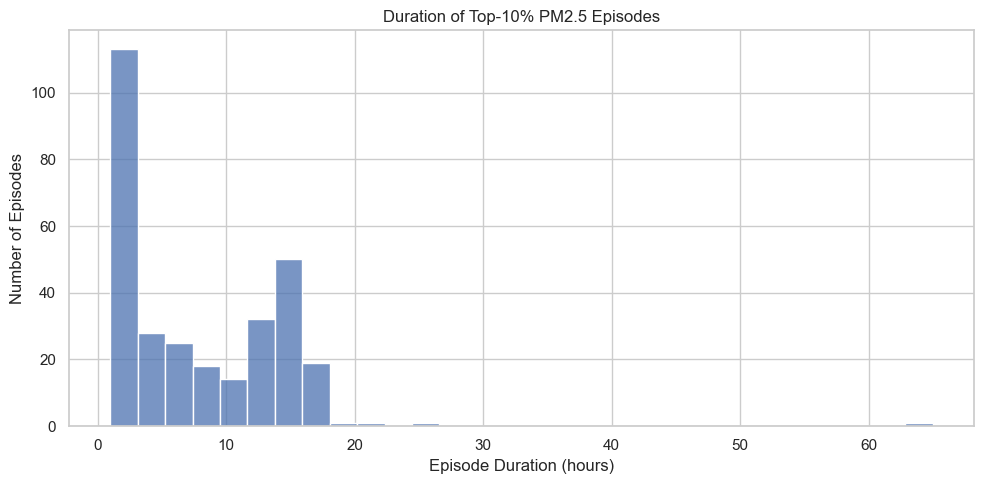

In [16]:
plt.figure(figsize=(10, 5))

sns.histplot(
    top10_episodes[
        'duration_hours'
    ],
    bins=30
)

plt.title(
    'Duration of Top-10% PM2.5 Episodes'
)

plt.xlabel(
    'Episode Duration (hours)'
)

plt.ylabel(
    'Number of Episodes'
)

plt.tight_layout()
plt.show()

In [17]:
#Duration categories
duration_bins = [
    0,
    1,
    2,
    5,
    11,
    23,
    np.inf
]

duration_labels = [
    '1 hour',
    '2 hours',
    '3–5 hours',
    '6–11 hours',
    '12–23 hours',
    '24+ hours'
]

top10_episodes[
    'duration_category'
] = pd.cut(
    top10_episodes[
        'duration_hours'
    ],
    bins=duration_bins,
    labels=duration_labels,
    include_lowest=True
)

In [18]:
top10_episodes[
    'duration_category'
].value_counts().reindex(
    duration_labels
)

duration_category
1 hour          49
2 hours         37
3–5 hours       55
6–11 hours      57
12–23 hours    103
24+ hours        2
Name: count, dtype: int64

## Most important episodes
longest episode
highest peak
largest total excess above threshold

In [19]:
#longest events
longest_events = (
    top10_episodes
    .sort_values(
        'duration_hours',
        ascending=False
    )
    .head(15)
)

longest_events[
    [
        'start_time',
        'end_time',
        'duration_hours',
        'mean_pm25',
        'peak_pm25',
        'excess_burden',
        'start_season'
    ]
].round(2)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


/var/folders/ty/nrt7j9nn2b17y8xxtd04s2xw0000gn/T/ipykernel_27834/4077093791.py:21: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(2)


,start_time,end_time,duration_hours,mean_pm25,peak_pm25,excess_burden,start_season
episode_id,,,,,,,
163,2024-11-25 17:00:00,2024-11-28 09:00:00,65,119.66,164.4,3481.5,Post-Monsoon
149,2024-11-16 07:00:00,2024-11-17 08:00:00,26,86.34,112.7,526.2,Post-Monsoon
279,2025-03-10 18:00:00,2025-03-11 15:00:00,22,95.71,132.7,651.4,Pre-Monsoon
70,2022-12-31 18:00:00,2023-01-01 12:00:00,19,80.89,98.5,281.0,Winter
89,2023-01-18 17:00:00,2023-01-19 10:00:00,18,91.46,105.7,456.4,Winter
68,2022-12-29 17:00:00,2022-12-30 10:00:00,18,94.73,110.6,515.4,Winter
69,2022-12-30 17:00:00,2022-12-31 09:00:00,17,92.80,102.0,453.9,Winter
146,2024-11-13 15:00:00,2024-11-14 07:00:00,17,92.68,115.9,451.9,Post-Monsoon
177,2024-12-07 17:00:00,2024-12-08 09:00:00,17,99.47,132.2,567.3,Winter


In [20]:
#highest peaks
highest_peak_events = (
    top10_episodes
    .sort_values(
        'peak_pm25',
        ascending=False
    )
    .head(15)
)

highest_peak_events[
    [
        'start_time',
        'duration_hours',
        'peak_time',
        'peak_pm25',
        'mean_pm25',
        'start_season'
    ]
].round(2)

/var/folders/ty/nrt7j9nn2b17y8xxtd04s2xw0000gn/T/ipykernel_27834/3831196380.py:20: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(2)


,start_time,duration_hours,peak_time,peak_pm25,mean_pm25,start_season
episode_id,,,,,,
230,2025-01-19 18:00:00,15,2025-01-19 23:00:00,170.4,122.33,Winter
163,2024-11-25 17:00:00,65,2024-11-26 22:00:00,164.4,119.66,Post-Monsoon
206,2024-12-28 17:00:00,16,2024-12-29 08:00:00,151.8,121.04,Winter
240,2025-01-29 18:00:00,16,2025-01-30 08:00:00,148.5,116.66,Winter
231,2025-01-20 18:00:00,15,2025-01-20 22:00:00,145.3,108.86,Winter
239,2025-01-28 18:00:00,15,2025-01-28 22:00:00,142.5,119.09,Winter
178,2024-12-08 17:00:00,17,2024-12-08 22:00:00,141.6,120.52,Winter
229,2025-01-18 19:00:00,14,2025-01-19 00:00:00,140.6,109.48,Winter
218,2025-01-08 19:00:00,13,2025-01-08 22:00:00,139.7,93.74,Winter


In [21]:
#Greatest excess burden
largest_burden_events = (
    top10_episodes
    .sort_values(
        'excess_burden',
        ascending=False
    )
    .head(15)
)

largest_burden_events[
    [
        'start_time',
        'end_time',
        'duration_hours',
        'peak_pm25',
        'mean_pm25',
        'excess_burden',
        'start_season'
    ]
].round(2)

/var/folders/ty/nrt7j9nn2b17y8xxtd04s2xw0000gn/T/ipykernel_27834/2118075338.py:21: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(2)


,start_time,end_time,duration_hours,peak_pm25,mean_pm25,excess_burden,start_season
episode_id,,,,,,,
163,2024-11-25 17:00:00,2024-11-28 09:00:00,65,164.4,119.66,3481.5,Post-Monsoon
178,2024-12-08 17:00:00,2024-12-09 09:00:00,17,141.6,120.52,925.1,Winter
206,2024-12-28 17:00:00,2024-12-29 08:00:00,16,151.8,121.04,879.1,Winter
230,2025-01-19 18:00:00,2025-01-20 08:00:00,15,170.4,122.33,843.5,Winter
241,2025-01-30 17:00:00,2025-01-31 08:00:00,16,136.9,117.58,823.6,Winter
240,2025-01-29 18:00:00,2025-01-30 09:00:00,16,148.5,116.66,808.9,Winter
239,2025-01-28 18:00:00,2025-01-29 08:00:00,15,142.5,119.09,794.8,Winter
271,2025-02-27 17:00:00,2025-02-28 08:00:00,16,125.3,108.48,678.1,Winter
279,2025-03-10 18:00:00,2025-03-11 15:00:00,22,132.7,95.71,651.4,Pre-Monsoon


## Seasonal concentration of episodes

In [22]:
season_hours = (
    hourly
    .groupby(
        'season',
        observed=False
    )
    .size()
    .reindex(
        season_order
    )
)

season_hours

season
Winter          6504
Pre-Monsoon     5880
Monsoon         6576
Post-Monsoon    4392
dtype: int64

In [23]:
#Episode starts by season
episode_season_counts = (
    top10_episodes[
        'start_season'
    ]
    .value_counts()
    .reindex(
        season_order,
        fill_value=0
    )
)

In [24]:
episode_season_rate = (
    episode_season_counts
    / season_hours
    * 1000
)

episode_season_summary = pd.DataFrame({
    'episodes':
        episode_season_counts,

    'observed_hours':
        season_hours,

    'episodes_per_1000_hours':
        episode_season_rate
})

episode_season_summary.round(2)

,episodes,observed_hours,episodes_per_1000_hours
Winter,204,6504,31.37
Pre-Monsoon,38,5880,6.46
Monsoon,1,6576,0.15
Post-Monsoon,60,4392,13.66


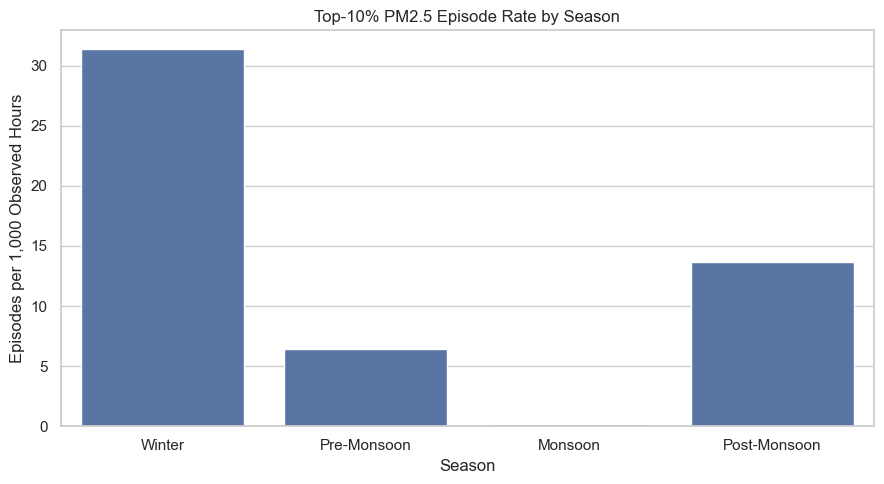

In [25]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=episode_season_rate.index,
    y=episode_season_rate.values
)

plt.title(
    'Top-10% PM2.5 Episode Rate by Season'
)

plt.xlabel('Season')

plt.ylabel(
    'Episodes per 1,000 Observed Hours'
)

plt.tight_layout()
plt.show()

## Extreme-hour rate by season

In [26]:
extreme_hour_rate_season = (
    hourly
    .groupby(
        'season',
        observed=False
    )['pm25_top10']
    .mean()
    * 100
)

extreme_hour_rate_season

season
Winter          25.307503
Pre-Monsoon      4.778912
Monsoon          0.015207
Post-Monsoon     9.699454
Name: pm25_top10, dtype: float64

## Monthly extreme-event rate

In [27]:
month_hours = (
    hourly
    .groupby('month')
    .size()
)

In [28]:
episode_month_counts = (
    top10_episodes[
        'start_month'
    ]
    .value_counts()
    .sort_index()
)

In [29]:
episode_month_rate = (
    episode_month_counts
    .reindex(
        range(1, 13),
        fill_value=0
    )
    /
    month_hours
    .reindex(
        range(1, 13)
    )
    * 1000
)

episode_month_rate

start_month
1     36.290323
2     21.568627
3      9.856631
4      6.944444
5      0.672043
6      0.694444
7      0.000000
8      0.000000
9      0.000000
10     1.792115
11    25.925926
12    35.394265
dtype: float64

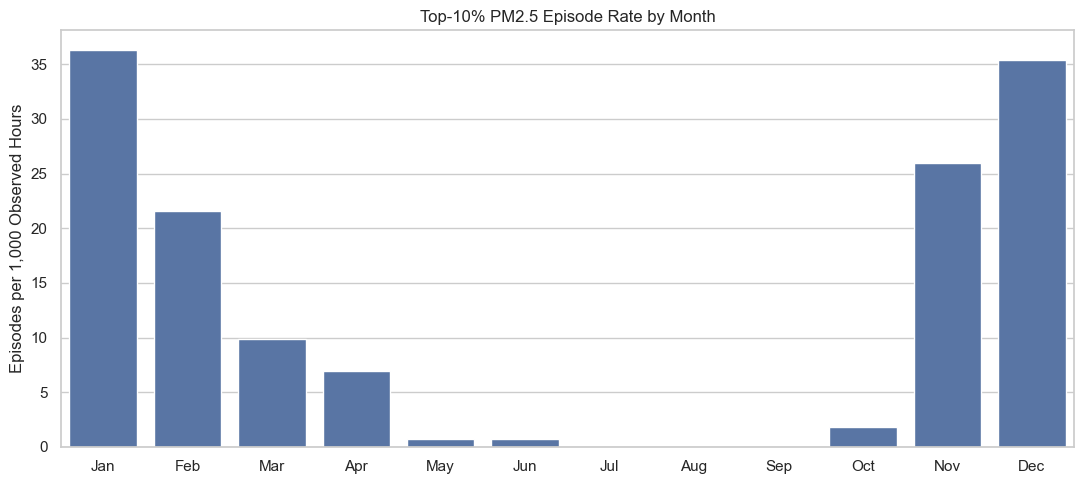

In [30]:
month_labels = [
    'Jan', 'Feb', 'Mar', 'Apr',
    'May', 'Jun', 'Jul', 'Aug',
    'Sep', 'Oct', 'Nov', 'Dec'
]

plt.figure(figsize=(11, 5))

sns.barplot(
    x=list(
        range(1, 13)
    ),
    y=episode_month_rate.values
)

plt.xticks(
    ticks=np.arange(12),
    labels=month_labels
)

plt.title(
    'Top-10% PM2.5 Episode Rate by Month'
)

plt.ylabel(
    'Episodes per 1,000 Observed Hours'
)

plt.tight_layout()
plt.show()

In [31]:
#Episode onset hour
episode_start_hour = (
    top10_episodes[
        'start_hour'
    ]
    .value_counts()
    .sort_index()
    .reindex(
        range(24),
        fill_value=0
    )
)

episode_start_hour

start_hour
0      4
1      3
2      0
3      0
4      1
5     11
6     10
7     30
8     17
9      0
10     0
11     1
12     0
13     1
14     0
15     2
16     3
17    25
18    37
19    55
20    50
21    28
22    18
23     7
Name: count, dtype: int64

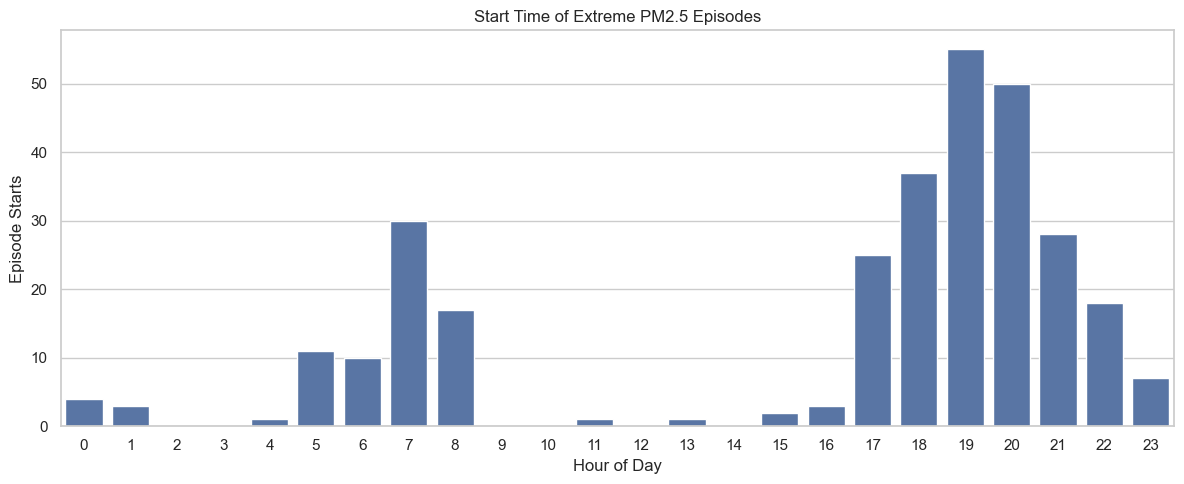

In [32]:
plt.figure(figsize=(12, 5))

sns.barplot(
    x=episode_start_hour.index,
    y=episode_start_hour.values
)

plt.title(
    'Start Time of Extreme PM2.5 Episodes'
)

plt.xlabel('Hour of Day')
plt.ylabel('Episode Starts')

plt.tight_layout()
plt.show()

## Conditional probability of extreme PM2.5

In [33]:
#Extreme probability by hour
extreme_by_hour = (
    hourly
    .groupby('hour')[
        'pm25_top10'
    ]
    .mean()
    * 100
)

extreme_by_hour

hour
0     18.499486
1     17.368962
2     15.724563
3     14.285714
4     12.846865
5     12.127441
6     12.846865
7     15.107914
8     12.744090
9      1.747174
10     0.719424
11     0.616650
12     0.616650
13     0.616650
14     0.616650
15     0.822199
16     1.027749
17     3.494347
18     7.297020
19    12.846865
20    17.677287
21    20.246660
22    21.685509
23    20.349435
Name: pm25_top10, dtype: float64

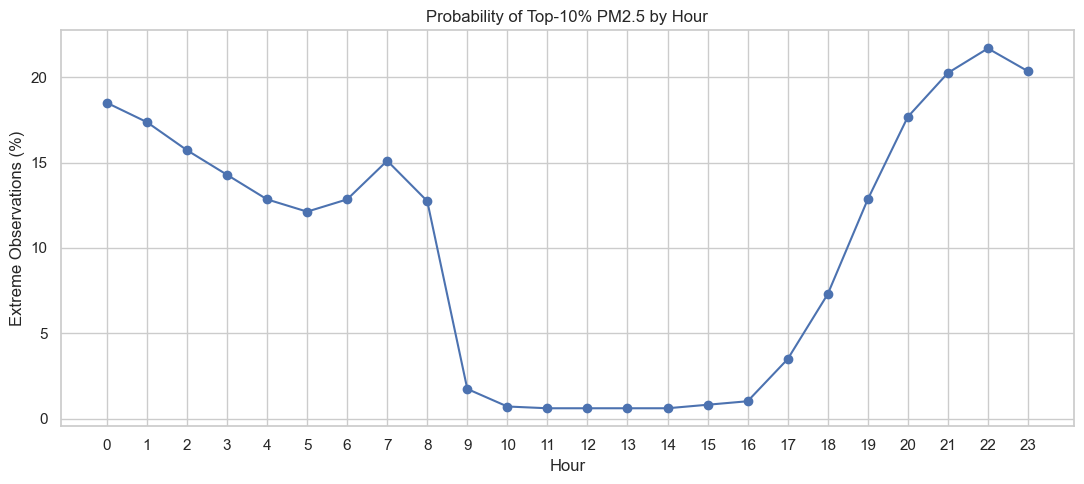

In [34]:
plt.figure(figsize=(11, 5))

plt.plot(
    extreme_by_hour.index,
    extreme_by_hour.values,
    marker='o'
)

plt.xticks(range(24))

plt.title(
    'Probability of Top-10% PM2.5 by Hour'
)

plt.xlabel('Hour')
plt.ylabel(
    'Extreme Observations (%)'
)

plt.tight_layout()
plt.show()

In [35]:
#Extreme probability by wind direction
extreme_by_wind = (
    hourly
    .groupby(
        'wind_sector',
        observed=False
    )['pm25_top10']
    .agg([
        'count',
        'sum',
        'mean'
    ])
    .reindex(
        wind_order
    )
)

extreme_by_wind[
    'extreme_percent'
] = (
    extreme_by_wind[
        'mean'
    ]
    * 100
)

extreme_by_wind

,count,sum,mean,extreme_percent
wind_sector,,,,
N,2339,226,0.096622,9.662249
NE,973,72,0.073998,7.399794
E,809,54,0.066749,6.674907
SE,1894,110,0.058078,5.807814
S,11134,1548,0.139034,13.903359
SW,810,14,0.017284,1.728395
W,1080,21,0.019444,1.944444
NW,4313,309,0.071644,7.164387


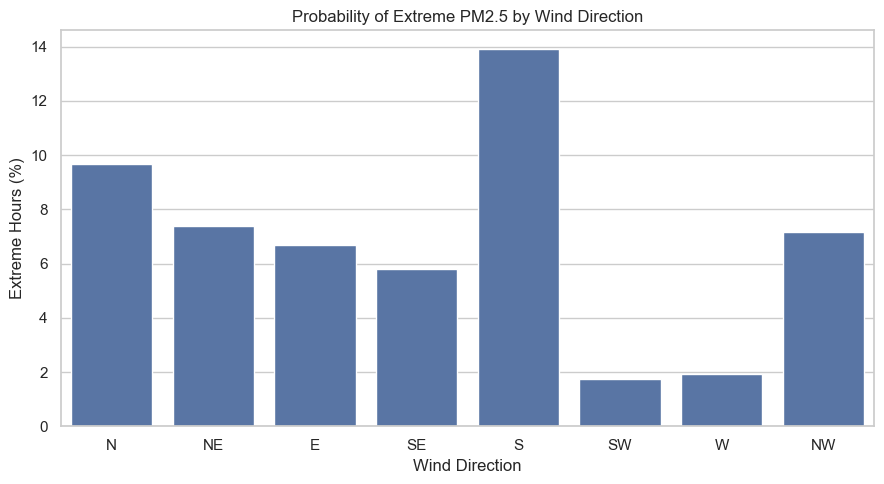

In [36]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=extreme_by_wind.index,
    y=extreme_by_wind[
        'extreme_percent'
    ]
)

plt.title(
    'Probability of Extreme PM2.5 by Wind Direction'
)

plt.xlabel(
    'Wind Direction'
)

plt.ylabel(
    'Extreme Hours (%)'
)

plt.tight_layout()
plt.show()

In [37]:
#Extreme probability during rain
extreme_by_rain = (
    hourly
    .groupby(
        'rain_status'
    )['pm25_top10']
    .agg([
        'count',
        'sum',
        'mean'
    ])
)

extreme_by_rain[
    'extreme_percent'
] = (
    extreme_by_rain[
        'mean'
    ]
    * 100
)

extreme_by_rain

,count,sum,mean,extreme_percent
rain_status,,,,
Dry,18325,2195,0.119782,11.978172
Rain,5027,159,0.031629,3.162920


## Meteorology during extreme hours

In [38]:
hourly[
    'extreme_group'
] = np.where(
    hourly[
        'pm25_top10'
    ] == 1,
    'Extreme',
    'Non-Extreme'
)

In [39]:
#Descriptive comparison
meteorology = [
    'temperature',
    'humidity',
    'wind_speed',
    'rain',
    'pressure',
    'dew_point'
]

In [40]:
extreme_weather_summary = (
    hourly
    .groupby(
        'extreme_group'
    )[meteorology]
    .agg([
        'mean',
        'median',
        'std'
    ])
)

extreme_weather_summary.round(2)

temperature              humidity               wind_speed  \
                     mean median   std     mean median    std       mean   
extreme_group                                                              
Extreme             11.90   10.8  5.01    74.01   78.0  20.59       4.47   
Non-Extreme         18.47   19.4  5.53    73.27   77.0  20.49       4.07   

                            rain              pressure              dew_point  \
              median   std  mean median   std     mean median   std      mean   
extreme_group                                                                   
Extreme          4.3  2.02  0.03    0.0  0.16   871.67  871.6  3.13      6.69   
Non-Extreme      3.6  2.34  0.25    0.0  1.09   871.19  871.2  3.29     12.84   

                            
              median   std  
extreme_group               
Extreme          6.6  3.54  
Non-Extreme     12.5  6.43

## Extreme days

In [41]:
daily_extreme = (
    hourly[
        'pm25_top10'
    ]
    .resample('D')
    .agg([
        'max',
        'sum'
    ])
)

daily_extreme.columns = [
    'extreme_day',
    'extreme_hours'
]

In [42]:
extreme_daily = (
    daily
    .join(
        daily_extreme,
        how='left'
    )
)

In [43]:
print(
    "Extreme days:",
    extreme_daily[
        'extreme_day'
    ].sum()
)

print(
    "Non-extreme days:",
    (
        extreme_daily[
            'extreme_day'
        ] == 0
    ).sum()
)

Extreme days: 257
Non-extreme days: 716


In [44]:
#Daily extreme weather comparison
daily_weather_vars = [
    'temperature_mean',
    'humidity_mean',
    'rain_total',
    'wind_speed_mean',
    'pressure_mean',
    'dew_point_mean'
]

In [45]:
daily_extreme_weather = (
    extreme_daily
    .groupby(
        'extreme_day'
    )[daily_weather_vars]
    .agg([
        'mean',
        'median',
        'std'
    ])
)

daily_extreme_weather.round(2)

temperature_mean              humidity_mean                \
                        mean median   std          mean median    std   
extreme_day                                                             
0                      19.42  20.56  3.98         74.72  80.38  15.94   
1                      13.33  12.90  2.87         69.51  70.75  10.66   

            rain_total               wind_speed_mean               \
                  mean median    std            mean median   std   
extreme_day                                                         
0                 7.05    1.5  13.62            4.06   3.99  1.09   
1                 0.73    0.0   2.31            4.23   4.20  0.69   

            pressure_mean               dew_point_mean               
                     mean  median   std           mean median   std  
extreme_day                                                          
0                  870.97  870.90  2.97          14.04  15.15  6.13  
1                  871.99  872.01  2.05           7.15   6.89  3.47

## Statistical comparison of extreme vs non-extreme days

In [46]:
extreme_weather_tests = []

for variable in daily_weather_vars:

    normal = (
        extreme_daily.loc[
            extreme_daily[
                'extreme_day'
            ] == 0,
            variable
        ]
        .dropna()
    )

    extreme = (
        extreme_daily.loc[
            extreme_daily[
                'extreme_day'
            ] == 1,
            variable
        ]
        .dropna()
    )

    test = mannwhitneyu(
        extreme,
        normal,
        alternative='two-sided'
    )

    effect_size = (
        2 * test.statistic
        /
        (
            len(extreme)
            * len(normal)
        )
        - 1
    )

    extreme_weather_tests.append({
        'variable':
            variable,

        'extreme_median':
            extreme.median(),

        'normal_median':
            normal.median(),

        'U':
            test.statistic,

        'p_raw':
            test.pvalue,

        'rank_biserial':
            effect_size
    })


extreme_weather_tests = pd.DataFrame(
    extreme_weather_tests
)

In [47]:
reject, p_holm, _, _ = (
    multipletests(
        extreme_weather_tests[
            'p_raw'
        ],
        method='holm'
    )
)

extreme_weather_tests[
    'p_holm'
] = p_holm

extreme_weather_tests[
    'significant_holm'
] = reject

In [48]:
extreme_weather_tests.round(4)

,variable,extreme_median,normal_median,U,p_raw,rank_biserial,p_holm,significant_holm
0,temperature_mean,12.9000,20.5625,22466.5,0.0000,-0.7558,0.0000,True
1,humidity_mean,70.7500,80.3750,61000.0,0.0000,-0.3370,0.0000,True
2,rain_total,0.0000,1.5000,46373.5,0.0000,-0.4960,0.0000,True
3,wind_speed_mean,4.1958,3.9937,105318.5,0.0006,0.1447,0.0006,True
4,pressure_mean,872.0083,870.8958,111184.0,0.0000,0.2084,0.0000,True
5,dew_point_mean,6.8917,15.1542,34079.0,0.0000,-0.6296,0.0000,True


## Logistic regression for extreme-hour probability

In [49]:
extreme_model_df = (
    hourly
    .copy()
)

In [50]:
extreme_model_df[
    'pm25_lag1'
] = (
    extreme_model_df[
        'pm25'
    ]
    .shift(1)
)

In [51]:
extreme_model_df[
    'log_rain'
] = np.log1p(
    extreme_model_df[
        'rain'
    ]
)

In [52]:
#Standardize continuous variables
extreme_predictors = [
    'temperature',
    'humidity',
    'wind_speed',
    'log_rain',
    'pressure',
    'pm25_lag1'
]

In [53]:
for variable in extreme_predictors:

    extreme_model_df[
        f'z_{variable}'
    ] = (
        extreme_model_df[
            variable
        ]
        - extreme_model_df[
            variable
        ].mean()
    ) / extreme_model_df[
        variable
    ].std()

In [54]:
extreme_model_df = (
    extreme_model_df
    .dropna()
    .copy()
)

In [55]:
#Environmental model
extreme_formula_context = """
pm25_top10 ~
z_temperature +
z_humidity +
z_wind_speed +
z_log_rain +
z_pressure +
wind_dir_sin +
wind_dir_cos +
C(hour) +
C(month)
"""

In [56]:
extreme_model_context = (
    smf.glm(
        formula=
            extreme_formula_context,

        data=
            extreme_model_df,

        family=
            sm.families.Binomial()
    )
    .fit(
        cov_type='HAC',
        cov_kwds={
            'maxlags': 24
        }
    )
)

In [57]:
print(
    extreme_model_context.summary()
)

                 Generalized Linear Model Regression Results                  
Dep. Variable:             pm25_top10   No. Observations:                23351
Model:                            GLM   Df Residuals:                    23309
Model Family:                Binomial   Df Model:                           41
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4603.8
Date:                Sun, 27 Sep 2026   Deviance:                       9207.5
Time:                        23:16:07   Pearson chi2:                 3.64e+04
No. Iterations:                    27   Pseudo R-squ. (CS):             0.2285
Covariance Type:                  HAC                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -0.0704      0.512     -0.

In [58]:
#Persistence-adjusted model
extreme_formula_persistence = """
pm25_top10 ~
z_temperature +
z_humidity +
z_wind_speed +
z_log_rain +
z_pressure +
wind_dir_sin +
wind_dir_cos +
z_pm25_lag1 +
C(hour) +
C(month)
"""

In [59]:
extreme_model_persistence = (
    smf.glm(
        formula=
            extreme_formula_persistence,

        data=
            extreme_model_df,

        family=
            sm.families.Binomial()
    )
    .fit(
        cov_type='HAC',
        cov_kwds={
            'maxlags': 24
        }
    )
)

## Odds ratios

In [60]:
extreme_terms = [
    'z_temperature',
    'z_humidity',
    'z_wind_speed',
    'z_log_rain',
    'z_pressure',
    'wind_dir_sin',
    'wind_dir_cos',
    'z_pm25_lag1'
]

In [61]:
available_terms = [
    term
    for term in extreme_terms
    if term in
    extreme_model_persistence.params.index
]

In [62]:
extreme_odds = pd.DataFrame({
    'coefficient':
        extreme_model_persistence
        .params[
            available_terms
        ],

    'p_value':
        extreme_model_persistence
        .pvalues[
            available_terms
        ],

    'ci_lower':
        extreme_model_persistence
        .conf_int()
        .loc[
            available_terms,
            0
        ],

    'ci_upper':
        extreme_model_persistence
        .conf_int()
        .loc[
            available_terms,
            1
        ]
})

In [63]:
extreme_odds[
    'odds_ratio'
] = np.exp(
    extreme_odds[
        'coefficient'
    ]
)

extreme_odds[
    'or_ci_lower'
] = np.exp(
    extreme_odds[
        'ci_lower'
    ]
)

extreme_odds[
    'or_ci_upper'
] = np.exp(
    extreme_odds[
        'ci_upper'
    ]
)

extreme_odds.round(4)

,coefficient,p_value,ci_lower,ci_upper,odds_ratio,or_ci_lower,or_ci_upper
z_temperature,-0.3338,0.1640,-0.8039,0.1363,0.7162,0.4476,1.1460
z_humidity,0.0201,0.8764,-0.2335,0.2738,1.0203,0.7917,1.3150
z_wind_speed,0.0123,0.8913,-0.1639,0.1884,1.0124,0.8489,1.2073
z_log_rain,-0.0823,0.6410,-0.4282,0.2636,0.9210,0.6517,1.3016
z_pressure,-0.2809,0.0015,-0.4541,-0.1077,0.7551,0.6350,0.8979
wind_dir_sin,0.6548,0.0034,0.2163,1.0933,1.9248,1.2415,2.9841
wind_dir_cos,0.1370,0.5425,-0.3039,0.5779,1.1468,0.7380,1.7823
z_pm25_lag1,6.5773,0.0000,6.0330,7.1216,718.6289,416.9822,1238.4883


In [64]:
#Joint wind-direction test
wind_direction_test = (
    extreme_model_persistence
    .wald_test(
        'wind_dir_sin = 0, '
        'wind_dir_cos = 0'
    )
)

print(
    wind_direction_test
)

<Wald test (chi2): statistic=8.595617285234281, p-value=0.013598325176407383, df_denom=2>


## Top-5% sensitivity model

In [65]:
extreme_formula_top5 = """
pm25_top5 ~
z_temperature +
z_humidity +
z_wind_speed +
z_log_rain +
z_pressure +
wind_dir_sin +
wind_dir_cos +
z_pm25_lag1 +
C(hour) +
C(month)
"""

In [66]:
extreme_model_top5 = (
    smf.glm(
        formula=
            extreme_formula_top5,

        data=
            extreme_model_df,

        family=
            sm.families.Binomial()
    )
    .fit(
        cov_type='HAC',
        cov_kwds={
            'maxlags': 24
        }
    )
)

## Event-centered pollution dynamics

In [67]:
sustained_events = (
    top10_episodes[
        top10_episodes[
            'duration_hours'
        ] >= 2
    ]
)

In [68]:
#Extract ±24-hour onset windows
event_profiles = []

for event_id, row in (
    sustained_events
    .iterrows()
):

    start = row[
        'start_time'
    ]

    window = hourly.loc[
        start
        - pd.Timedelta(
            hours=24
        ):
        start
        + pd.Timedelta(
            hours=48
        ),
        ['pm25']
    ].copy()

    window[
        'relative_hour'
    ] = (
        (
            window.index
            - start
        )
        / pd.Timedelta(
            hours=1
        )
    ).astype(int)

    window[
        'episode_id'
    ] = event_id

    event_profiles.append(
        window
    )

In [69]:
event_profiles = pd.concat(
    event_profiles
)

In [70]:
event_profile_summary = (
    event_profiles
    .groupby(
        'relative_hour'
    )['pm25']
    .agg([
        'mean',
        'median',
        'count'
    ])
)

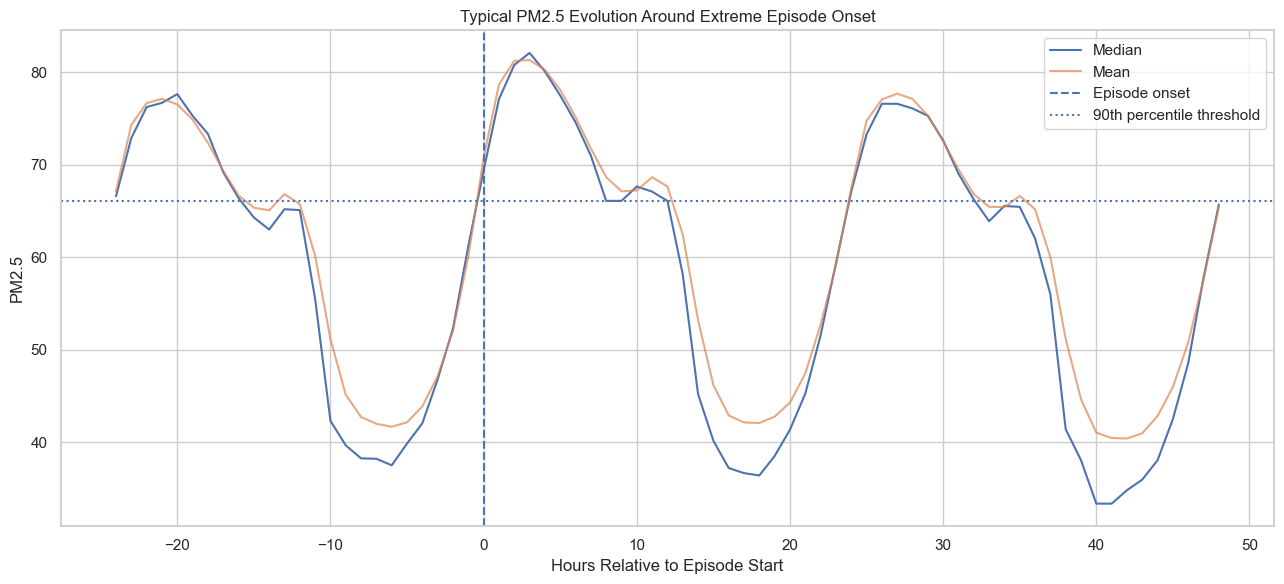

In [71]:
plt.figure(figsize=(13, 6))

plt.plot(
    event_profile_summary.index,
    event_profile_summary[
        'median'
    ],
    label='Median'
)

plt.plot(
    event_profile_summary.index,
    event_profile_summary[
        'mean'
    ],
    alpha=0.7,
    label='Mean'
)

plt.axvline(
    0,
    linestyle='--',
    label='Episode onset'
)

plt.axhline(
    pm25_p90,
    linestyle=':',
    label='90th percentile threshold'
)

plt.title(
    'Typical PM2.5 Evolution Around '
    'Extreme Episode Onset'
)

plt.xlabel(
    'Hours Relative to Episode Start'
)

plt.ylabel('PM2.5')

plt.legend()

plt.tight_layout()
plt.show()

## AQI extreme-day episodes

In [72]:
#Daily AQI episode function
def build_daily_aqi_episodes(
    df,
    flag_col
):

    temp = df.copy()

    flag = (
        temp[flag_col]
        .astype(bool)
    )

    starts = (
        flag
        & ~flag.shift(
            1,
            fill_value=False
        )
    )

    temp[
        'episode_id'
    ] = starts.cumsum()

    temp.loc[
        ~flag,
        'episode_id'
    ] = np.nan

    event_days = (
        temp.loc[flag]
        .copy()
    )

    event_days[
        'episode_id'
    ] = (
        event_days[
            'episode_id'
        ].astype(int)
    )

    event_reset = (
        event_days
        .reset_index()
    )

    episodes = (
        event_reset
        .groupby(
            'episode_id'
        )
        .agg(
            start_date=(
                'time',
                'min'
            ),

            end_date=(
                'time',
                'max'
            ),

            duration_days=(
                'time',
                'size'
            ),

            mean_aqi=(
                'particle_aqi',
                'mean'
            ),

            peak_aqi=(
                'particle_aqi',
                'max'
            ),

            mean_pm25=(
                'pm25_mean',
                'mean'
            )
        )
    )

    return (
        event_days,
        episodes
    )

In [73]:
#AQI >100 episodes
aqi100_days, aqi100_episodes = (
    build_daily_aqi_episodes(
        daily,
        'aqi_over_100'
    )
)

In [74]:
#AQI >150 episodes
aqi150_days, aqi150_episodes = (
    build_daily_aqi_episodes(
        daily,
        'aqi_over_150'
    )
)

In [75]:
aqi_episode_summary = pd.DataFrame({
    'AQI > 100': {
        'Days':
            len(aqi100_days),

        'Episodes':
            len(aqi100_episodes),

        'Median duration':
            aqi100_episodes[
                'duration_days'
            ].median(),

        'Longest episode':
            aqi100_episodes[
                'duration_days'
            ].max(),

        'Maximum AQI':
            aqi100_episodes[
                'peak_aqi'
            ].max()
    },

    'AQI > 150': {
        'Days':
            len(aqi150_days),

        'Episodes':
            len(aqi150_episodes),

        'Median duration':
            aqi150_episodes[
                'duration_days'
            ].median(),

        'Longest episode':
            aqi150_episodes[
                'duration_days'
            ].max(),

        'Maximum AQI':
            aqi150_episodes[
                'peak_aqi'
            ].max()
    }
})

aqi_episode_summary.round(2)

,AQI > 100,AQI > 150
Days,397.0,145.0
Episodes,56.0,24.0
Median duration,3.0,2.5
Longest episode,112.0,66.0
Maximum AQI,196.0,196.0


In [76]:
#Longest unhealthy AQI periods
aqi100_episodes.sort_values(
    'duration_days',
    ascending=False
).head(15)

,start_date,end_date,duration_days,mean_aqi,peak_aqi,mean_pm25
episode_id,,,,,,
50,2024-11-09,2025-02-28,112,158.044643,196,68.121763
2,2022-11-02,2022-12-13,42,141.452381,162,53.466964
3,2022-12-16,2023-01-06,22,144.409091,172,58.421023
4,2023-01-08,2023-01-26,19,132.105263,169,51.476974
5,2023-01-28,2023-02-11,15,132.400000,156,48.620000
52,2025-03-21,2025-04-03,14,128.714286,154,47.353869
46,2024-06-08,2024-06-18,11,127.090909,139,46.144318
6,2023-02-13,2023-02-22,10,116.300000,125,41.737917
7,2023-02-24,2023-03-05,10,125.700000,149,45.576250


In [77]:
aqi150_episodes.sort_values(
    'duration_days',
    ascending=False
).head(15)

,start_date,end_date,duration_days,mean_aqi,peak_aqi,mean_pm25
episode_id,,,,,,
18,2024-12-18,2025-02-21,66,161.696970,181,70.787058
17,2024-12-03,2024-12-15,13,159.769231,180,67.820833
8,2022-12-28,2023-01-04,8,164.750000,172,75.311979
20,2025-03-07,2025-03-13,7,166.000000,180,76.969048
14,2024-11-13,2024-11-17,5,166.600000,169,77.725000
16,2024-11-25,2024-11-29,5,176.600000,196,92.015833
9,2023-01-16,2023-01-20,5,163.600000,169,73.414167
19,2025-02-24,2025-02-28,5,158.200000,162,65.593333
2,2022-11-13,2022-11-17,5,155.200000,160,61.777500


In [78]:
#results
episode_summary.to_csv(
    TABLES_DIR /
    "episode_summary.csv"
)

top10_episodes.to_csv(
    TABLES_DIR /
    "top10_pm25_episodes.csv"
)

top5_episodes.to_csv(
    TABLES_DIR /
    "top5_pm25_episodes.csv"
)

episode_season_summary.to_csv(
    TABLES_DIR /
    "episode_rate_by_season.csv"
)

extreme_by_wind.to_csv(
    TABLES_DIR /
    "extreme_rate_by_wind_sector.csv"
)

extreme_by_rain.to_csv(
    TABLES_DIR /
    "extreme_rate_by_rain_status.csv"
)

extreme_weather_tests.to_csv(
    TABLES_DIR /
    "extreme_weather_tests.csv",
    index=False
)

extreme_odds.to_csv(
    TABLES_DIR /
    "extreme_logistic_odds_ratios.csv"
)

aqi100_episodes.to_csv(
    TABLES_DIR /
    "aqi_over_100_episodes.csv"
)

aqi150_episodes.to_csv(
    TABLES_DIR /
    "aqi_over_150_episodes.csv"
)

In [79]:
print("=" * 76)
print(
    "PHASE 7 — EXTREME POLLUTION EVENT ANALYSIS"
)
print("=" * 76)


print("\nPM2.5 THRESHOLDS")

print(
    f"Top 10% threshold: "
    f"{pm25_p90:.2f}"
)

print(
    f"Top 5% threshold: "
    f"{pm25_p95:.2f}"
)


print("\nEPISODE SUMMARY")

print(
    episode_summary.round(2)
)


print(
    "\nTOP-10% EPISODE RATE BY SEASON"
)

print(
    episode_season_summary.round(2)
)


print(
    "\nEXTREME RATE BY WIND DIRECTION"
)

print(
    extreme_by_wind[
        [
            'count',
            'sum',
            'extreme_percent'
        ]
    ].round(2)
)


print(
    "\nEXTREME RATE BY RAIN STATUS"
)

print(
    extreme_by_rain[
        [
            'count',
            'sum',
            'extreme_percent'
        ]
    ].round(2)
)


print(
    "\nEXTREME VS NON-EXTREME DAYS"
)

print(
    extreme_weather_tests[
        [
            'variable',
            'extreme_median',
            'normal_median',
            'p_holm',
            'rank_biserial'
        ]
    ].round(4)
)


print(
    "\nPERSISTENCE-ADJUSTED "
    "EXTREME ODDS RATIOS"
)

print(
    extreme_odds[
        [
            'odds_ratio',
            'or_ci_lower',
            'or_ci_upper',
            'p_value'
        ]
    ].round(4)
)


print(
    "\nAQI EPISODES"
)

print(
    aqi_episode_summary.round(2)
)


print(
    "\nLONGEST TOP-10% PM2.5 EPISODES"
)

print(
    longest_events[
        [
            'start_time',
            'end_time',
            'duration_hours',
            'mean_pm25',
            'peak_pm25',
            'excess_burden',
            'start_season'
        ]
    ]
    .head(10)
    .round(2)
)


print("\n" + "=" * 76)

PHASE 7 — EXTREME POLLUTION EVENT ANALYSIS

PM2.5 THRESHOLDS
Top 10% threshold: 66.10
Top 5% threshold: 83.60

EPISODE SUMMARY
                           Top 10%   Top 5%
Extreme hours              2354.00  1177.00
Episodes                    303.00   188.00
Sustained episodes (>=2h)   254.00   162.00
Median duration               6.00     5.00
Mean duration                 7.77     6.26
Maximum duration             65.00    18.00
Median peak PM2.5            81.30   102.35

TOP-10% EPISODE RATE BY SEASON
              episodes  observed_hours  episodes_per_1000_hours
Winter             204            6504                    31.37
Pre-Monsoon         38            5880                     6.46
Monsoon              1            6576                     0.15
Post-Monsoon        60            4392                    13.66

EXTREME RATE BY WIND DIRECTION
             count   sum  extreme_percent
wind_sector                              
N             2339   226             9.66
NE         

/var/folders/ty/nrt7j9nn2b17y8xxtd04s2xw0000gn/T/ipykernel_27834/2524657200.py:127: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(2)


In [80]:
print(episode_summary.round(2))

print(episode_season_summary.round(2))

print(
    top10_episodes[
        'duration_hours'
    ].describe()
)

print(
    longest_events.head(10)
)

print(
    largest_burden_events.head(10)
)

print(
    extreme_by_wind.round(3)
)

print(
    extreme_by_rain.round(3)
)

print(
    extreme_weather_tests.round(4)
)

print(
    extreme_odds.round(4)
)

print(
    wind_direction_test
)

print(
    aqi_episode_summary.round(2)
)

                           Top 10%   Top 5%
Extreme hours              2354.00  1177.00
Episodes                    303.00   188.00
Sustained episodes (>=2h)   254.00   162.00
Median duration               6.00     5.00
Mean duration                 7.77     6.26
Maximum duration             65.00    18.00
Median peak PM2.5            81.30   102.35
              episodes  observed_hours  episodes_per_1000_hours
Winter             204            6504                    31.37
Pre-Monsoon         38            5880                     6.46
Monsoon              1            6576                     0.15
Post-Monsoon        60            4392                    13.66
count    303.000000
mean       7.768977
std        6.552344
min        1.000000
25%        2.000000
50%        6.000000
75%       13.000000
max       65.000000
Name: duration_hours, dtype: float64
                    start_time            end_time  duration_hours  \
episode_id                                                   

In [81]:
def extract_odds_ratios(
    model,
    terms
):

    available = [
        term
        for term in terms
        if term in model.params.index
    ]

    result = pd.DataFrame({
        'coefficient':
            model.params[available],

        'p_value':
            model.pvalues[available]
    })

    result[
        'odds_ratio'
    ] = np.exp(
        result['coefficient']
    )

    return result

In [82]:
top10_or = extract_odds_ratios(
    extreme_model_persistence,
    extreme_terms
)

top5_or = extract_odds_ratios(
    extreme_model_top5,
    extreme_terms
)

In [83]:
severity_sensitivity = pd.DataFrame({
    'OR_top10':
        top10_or[
            'odds_ratio'
        ],

    'p_top10':
        top10_or[
            'p_value'
        ],

    'OR_top5':
        top5_or[
            'odds_ratio'
        ],

    'p_top5':
        top5_or[
            'p_value'
        ]
})

severity_sensitivity.round(4)

,OR_top10,p_top10,OR_top5,p_top5
z_temperature,0.7162,0.1640,0.9309,0.7717
z_humidity,1.0203,0.8764,1.1040,0.4590
z_wind_speed,1.0124,0.8913,1.0685,0.0427
z_log_rain,0.9210,0.6410,0.2005,0.0000
z_pressure,0.7551,0.0015,0.8976,0.2640
wind_dir_sin,1.9248,0.0034,0.9459,0.1879
wind_dir_cos,1.1468,0.5425,2.1051,0.0000
z_pm25_lag1,718.6289,0.0000,730.6986,0.0000


## Phase 7 Summary: Extreme Pollution Event Analysis

Extreme PM2.5 concentrations in Kathmandu generally occurred as sustained
episodes rather than isolated hourly spikes. Using the study-wide 90th
percentile threshold of 66.1, 2,354 extreme hours were grouped into 303
episodes, of which 254 lasted at least two consecutive hours. The median
episode duration was six hours, while the longest episode persisted for
65 consecutive hours.

Extreme pollution demonstrated pronounced seasonal clustering. Winter
recorded approximately 31.4 episode starts per 1,000 observed hours,
compared with 13.7 during post-monsoon, 6.5 during pre-monsoon, and only
0.15 during monsoon. Episode occurrence was similarly concentrated in
November through February and was almost absent during the core monsoon
months.

A strong diurnal structure was also evident. Extreme-event probability
was lowest during the middle of the day and increased substantially
during the evening, while new episodes most frequently began during the
late afternoon and evening. Event-centered analysis further demonstrated
a recurring daily cycle around episode onset.

Wind conditions were associated with large differences in extreme-event
frequency. Approximately 13.9% of observations with southerly winds were
classified as extreme, compared with less than 2% for southwesterly and
westerly winds. Wind direction remained jointly associated with extreme
status after adjustment for temporal and meteorological variables.

Rainy conditions were associated descriptively with considerably fewer
extreme observations: approximately 3.2% of rainy hours were extreme,
compared with approximately 12.0% of dry hours. Extreme days were also
colder, drier, characterized by lower dew point, and slightly higher in
surface pressure than non-extreme days. However, several of these
unadjusted meteorological differences weakened after adjustment for
temporal structure and previous PM2.5, demonstrating substantial
confounding by season and pollution persistence.

Previous-hour PM2.5 was by far the strongest predictor of continued
extreme status, reinforcing the strong short-term persistence identified
during the time-series analysis. This result is consistent with the high
proportion of multi-hour pollution episodes.

Poor daily particulate-AQI conditions also occurred in prolonged
sequences. The calculated particulate AQI exceeded 100 on 397 days,
grouped into 56 episodes, and exceeded 150 on 145 days, grouped into 24
episodes. The longest continuous periods above these thresholds lasted
112 and 66 days, respectively.

Overall, extreme air pollution in Kathmandu was characterized by strong
winter concentration, pronounced evening timing, persistence across
multiple consecutive hours or days, distinct wind-direction patterns,
and substantially lower occurrence during rainy and monsoon conditions.